In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import pickle
import numpy as np
import os

# 1. GPU 설정 (가능하면 GPU 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

# 2. 전처리 데이터 로드
load_path = '../data/processed_data.pkl'

if os.path.exists(load_path):
    with open(load_path, 'rb') as f:
        saved_data = pickle.load(f)
    patient_history = saved_data['patient_history']
    vocabs = saved_data['vocabs']
    print(f"✅ 데이터 로드 완료! (환자 수: {len(patient_history)}명)")
else:
    print(f"❌ 오류: '{load_path}' 파일이 없습니다. 03_preprocessing.ipynb를 먼저 실행해주세요.")

사용 장치: cpu
✅ 데이터 로드 완료! (환자 수: 100명)


In [41]:
# 1. 입원 기록 파일 경로 찾기 (압축된 경우 대비)
path_hosp = '../data/hosp/'
file_path = os.path.join(path_hosp, 'admissions.csv')
if os.path.exists(file_path + '.gz'):
    file_path += '.gz'

# 2. CSV 로드
try:
    df_adm = pd.read_csv(file_path)
    print("✅ 입원 기록(Admissions) 로드 완료")
except FileNotFoundError:
    print("❌ 입원 기록 파일을 찾을 수 없습니다.")

# 3. 환자별 사망 여부 사전 만들기 (0: 생존, 1: 사망)
mortality_dict = {}
for pid, group in df_adm.groupby('subject_id'):
    # 한 번이라도 사망 기록(1)이 있으면 사망으로 간주
    if group['hospital_expire_flag'].sum() > 0:
        mortality_dict[pid] = 1.0
    else:
        mortality_dict[pid] = 0.0

print(f"✅ 정답지 생성 완료! (사망 케이스: {int(sum(mortality_dict.values()))}명)")

✅ 입원 기록(Admissions) 로드 완료
✅ 정답지 생성 완료! (사망 케이스: 15명)


In [42]:
# 1. 데이터셋 클래스 (Dataset)
class MIMICDataset(Dataset):
    def __init__(self, patient_history, labels, max_len=50):
        self.patient_ids = list(patient_history.keys())
        self.history = patient_history
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, idx):
        pid = self.patient_ids[idx]
        visits = self.history[pid]
        
        # 데이터 가져오기 (없으면 빈 리스트)
        diag_seq = [v.get('conditions', []) for v in visits]
        proc_seq = [v.get('procedures', []) for v in visits]
        drug_seq = [v.get('drugs', []) for v in visits]
        
        # 길이 자르기 (최근 데이터 위주)
        diag_seq = diag_seq[-self.max_len:]
        proc_seq = proc_seq[-self.max_len:]
        drug_seq = drug_seq[-self.max_len:]

        # 정답 라벨 (없으면 0.0)
        label = self.labels.get(pid, 0.0)

        return {
            'patient_id': pid,
            'num_visits': len(diag_seq),  # <--- 필수! (방문 횟수)
            'diagnosis': diag_seq,
            'procedure': proc_seq,
            'medication': drug_seq,
            'label': torch.tensor([label], dtype=torch.float32)
        }

# 2. 배치 처리 함수 (Collator)
def collate_fn(batch):
    # 가장 긴 방문 길이 찾기
    max_visits = max([sample['num_visits'] for sample in batch])
    batch_size = len(batch)
    
    # 단어장 크기 가져오기
    num_diag = len(vocabs['diag'])
    num_proc = len(vocabs['proc'])
    num_drug = len(vocabs['drug'])

    # 빈 텐서 만들기 (Multi-hot Encoding용)
    tensor_diag = torch.zeros((batch_size, max_visits, num_diag))
    tensor_proc = torch.zeros((batch_size, max_visits, num_proc))
    tensor_drug = torch.zeros((batch_size, max_visits, num_drug))
    
    labels = [] # 라벨 모음

    for i, sample in enumerate(batch):
        visits = sample['num_visits']
        labels.append(sample['label'])
        
        # 데이터 채워넣기 (해당하는 코드 위치를 1로 설정)
        for t in range(visits):
            for code in sample['diagnosis'][t]:
                if code < num_diag: tensor_diag[i, t, code] = 1
            for code in sample['procedure'][t]:
                if code < num_proc: tensor_proc[i, t, code] = 1
            for code in sample['medication'][t]:
                if code < num_drug: tensor_drug[i, t, code] = 1

    return {
        'diagnosis': tensor_diag,
        'procedure': tensor_proc,
        'medication': tensor_drug,
        'label': torch.stack(labels), # 라벨을 하나로 묶음
        'patient_ids': [s['patient_id'] for s in batch]
    }

# 데이터로더 생성
dataset = MIMICDataset(patient_history, mortality_dict)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
print("✅ 데이터로더 준비 완료!")

✅ 데이터로더 준비 완료!


In [43]:
class EHR_GRU(nn.Module):
    def __init__(self, vocab_sizes, hidden_dim=64, output_dim=1):
        super(EHR_GRU, self).__init__()
        
        input_dim = sum(vocab_sizes) # 진단+시술+약물 전체 크기
        
        # 입력 차원 축소 (Linear)
        self.embedding = nn.Linear(input_dim, hidden_dim)
        
        # GRU Layer
        self.gru = nn.GRU(input_size=hidden_dim, hidden_size=hidden_dim, batch_first=True)
        
        # 분류기 (Classifier)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, diag, proc, med):
        # 3가지 입력을 옆으로 이어 붙임
        x = torch.cat([diag, proc, med], dim=-1)
        
        x = torch.relu(self.embedding(x))
        x = self.dropout(x)
        
        # GRU 통과 (output, hidden)
        _, h_n = self.gru(x)
        
        # 마지막 시점의 Hidden State 사용
        last_hidden = h_n.squeeze(0)
        
        return self.fc(last_hidden)

print("✅ GRU 모델 클래스 정의 완료!")

✅ GRU 모델 클래스 정의 완료!


In [44]:
# 1. 모델 설정
vocab_sizes = (len(vocabs['diag']), len(vocabs['proc']), len(vocabs['drug']))
model = EHR_GRU(vocab_sizes, hidden_dim=64).to(device)

# 2. 학습 도구
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. 기록용 리스트 초기화 (여기가 바뀐 부분!)
train_losses = []
train_accs = []

# 4. 학습 루프
num_epochs = 10
print(f"=== 학습 시작 (Total Epochs: {num_epochs}) ===")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in dataloader:
        # GPU 이동
        diag = batch['diagnosis'].to(device)
        proc = batch['procedure'].to(device)
        med = batch['medication'].to(device)
        labels = batch['label'].to(device)
        
        # 예측 및 학습
        outputs = model(diag, proc, med)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # 정확도 계산
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        
    # 에폭별 평균 값 계산
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    
    # 리스트에 저장 (Append)
    train_losses.append(avg_loss)
    train_accs.append(accuracy)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f} | Acc: {accuracy:.2f}%")

print("=== 학습 완료! ===")

=== 학습 시작 (Total Epochs: 10) ===
Epoch [1/10] | Loss: 0.6932 | Acc: 50.00%
Epoch [2/10] | Loss: 0.6420 | Acc: 85.00%
Epoch [3/10] | Loss: 0.5754 | Acc: 85.00%
Epoch [4/10] | Loss: 0.4489 | Acc: 85.00%
Epoch [5/10] | Loss: 0.3658 | Acc: 85.00%
Epoch [6/10] | Loss: 0.3801 | Acc: 85.00%
Epoch [7/10] | Loss: 0.3799 | Acc: 85.00%
Epoch [8/10] | Loss: 0.3181 | Acc: 86.00%
Epoch [9/10] | Loss: 0.3333 | Acc: 86.00%
Epoch [10/10] | Loss: 0.2464 | Acc: 87.00%
=== 학습 완료! ===


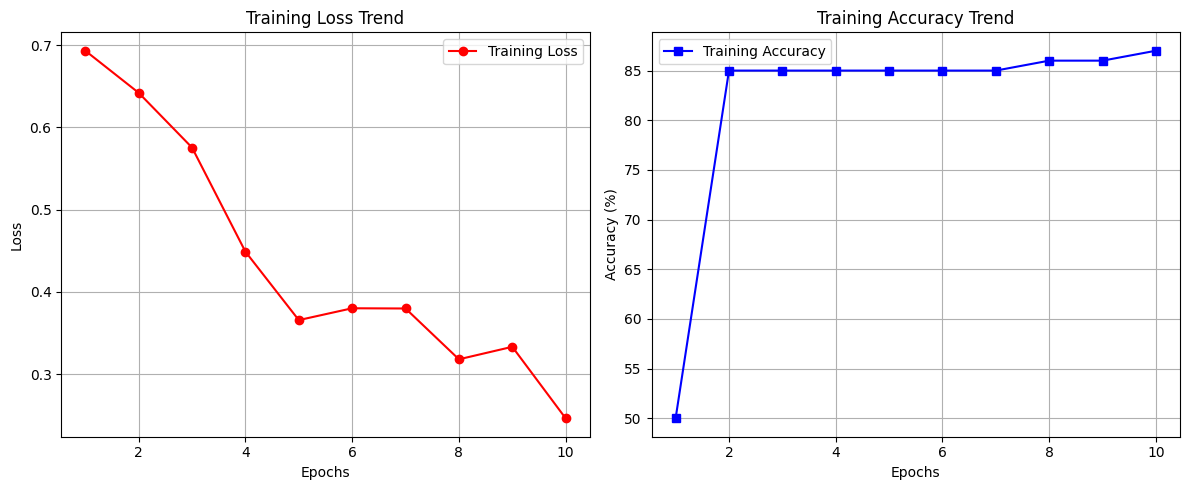

In [45]:
import matplotlib.pyplot as plt

# Epoch 축 생성 (1부터 10까지)
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# 1. Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'r-o', label='Training Loss')
plt.title('Training Loss Trend')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, 'b-s', label='Training Accuracy')
plt.title('Training Accuracy Trend')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()

# 이미지 저장 (폴더가 없으면 생성)
import os
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/training_result_gru.png')

plt.show()

In [46]:
# 모델 저장 경로 설정
save_path = '../data/ehr_gru_model.pth'

# 모델의 가중치(Weight) 저장
torch.save(model.state_dict(), save_path)

print(f"💾 모델이 성공적으로 저장되었습니다: {save_path}")

💾 모델이 성공적으로 저장되었습니다: ../data/ehr_gru_model.pth
